# Deco2018-style two-stage fitting example

This notebook demonstrates a compact `nmp_modeling` workflow for fitting a heterogeneous two-state BEI-DMF model with `Neuronumba`.

The example uses a shared structural connectivity matrix, multi-subject empirical time series, and a receptor map to implement a Deco2018-style two-stage fitting workflow:

1. **Stage A:** Scan the global coupling parameter `G` with receptor gain fixed at zero. FC is recorded for reference, but FCD is used as the fitting target.
2. **Stage B:** Fix the best `G` from Stage A and scan the receptor gain parameter `gain_e`. Placebo and LSD FCDs are recorded for comparison.

Expected local files in the same directory as this notebook:

- `src/`: local [`Neuronumba`](https://github.com/neich/neuronumba/tree/main/src) source tree. This folder is not part of this GitHub repository.
- `all_SC_FC_TC_76_90_116.mat`: structural connectivity data.
- `LSDnew.mat`: empirical time series data.
- `mean5HT2A_bindingaal.mat`: receptor map data.

The notebook uses the current notebook directory and searches upward for the project package.

In [ ]:
# Cell 1: path setup, imports, and filtering choice
# The local Neuronumba source tree is expected at ./src next to this notebook.
# The nmp_modeling package is found by walking upward from the current directory.

from pathlib import Path
import sys

HERE = Path.cwd().resolve()
NEURONUMBA_SRC = HERE / "src"
PROJECT_ROOT = next(
    (p for p in [HERE, *HERE.parents] if (p / "nmp_modeling").exists()),
    None,
)

if not NEURONUMBA_SRC.exists():
    raise RuntimeError("Expected local Neuronumba source folder at ./src next to this notebook.")
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root containing the nmp_modeling package.")

for path in [PROJECT_ROOT, NEURONUMBA_SRC]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import numpy as np
import hdf5storage as hdf
import matplotlib.pyplot as plt

from nmp_modeling.parametrization import FreeParam, MapParametrization
from nmp_modeling.adapters.neuronumba import NeuronumbaAdapter
from nmp_modeling.observable_specs import make_empirical_target
from nmp_modeling.fitting import grid_sweep

from nmp_modeling.preprocessing import make_bandpass_filter
bandpass = make_bandpass_filter()  # Default: 0.01–0.1 Hz, TR=2.0 s, Butterworth order=2.

In [ ]:
# Cell 2: load and format empirical data
# This cell is dataset-specific. It prepares arrays for the modeling workflow but does not
# run any model fitting itself.

PLACEBO = 4
LSD = 1

SC_FILE = HERE / "all_SC_FC_TC_76_90_116.mat"
TS_FILE = HERE / "LSDnew.mat"
RECEPTOR_FILE = HERE / "mean5HT2A_bindingaal.mat"

for file_path in [SC_FILE, TS_FILE, RECEPTOR_FILE]:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required local data file: {file_path}")

# Structural connectivity is normalized to a commonly used scale in whole-brain modeling.
C = hdf.loadmat(str(SC_FILE))["sc90"].astype(float)
C = 0.2 * C / C.max()

tc_aal = hdf.loadmat(str(TS_FILE))["tc_aal"]

# The receptor map is normalized to [0, 1] and later used as gain_map_e.
receptor = hdf.loadmat(str(RECEPTOR_FILE))["mean5HT2A_aalsymm"][:, 0].astype(float)
receptor = receptor / receptor.max()


def reorder_aal90_lr(roi_by_time):
    """Return a time-by-node AAL90 matrix in the node order used by this example."""
    return np.vstack([roi_by_time[0:90:2], roi_by_time[1:90:2][::-1]]).T


# Multi-subject empirical time series are stored as (subjects, time, nodes).
# make_empirical_target() can use this stack directly and aggregate subject-level observables.
TS_PLACEBO_ALL = np.stack(
    [reorder_aal90_lr(tc_aal[s, PLACEBO]) for s in range(tc_aal.shape[0])],
    axis=0,
)
TS_LSD_ALL = np.stack(
    [reorder_aal90_lr(tc_aal[s, LSD]) for s in range(tc_aal.shape[0])],
    axis=0,
)

print("SC shape              :", C.shape)
print("Receptor map shape    :", receptor.shape)
print("Placebo time series   :", TS_PLACEBO_ALL.shape)
print("LSD time series       :", TS_LSD_ALL.shape)

SC shape              : (90, 90)
Receptor map shape    : (90,)
Placebo time series   : (15, 220, 90)
LSD time series       : (15, 220, 90)


In [ ]:
# Cell 3: create empirical targets and the Neuronumba adapter

placebo_fc = make_empirical_target(
    data=TS_PLACEBO_ALL,
    observable="fc_corr_z",
)
placebo_fcd = make_empirical_target(
    data=TS_PLACEBO_ALL,
    observable="fcd_ks",
    label="placebo_fcd",
    preprocess=bandpass,
)
lsd_fcd = make_empirical_target(
    data=TS_LSD_ALL,
    observable="fcd_ks",
    label="lsd_fcd",
    preprocess=bandpass,
)

# MapParametrization keeps the model setup explicit while allowing grid_sweep to vary parameters.
gain_map_e_param = MapParametrization(
    target="gain_map_e",
    expression="gain_map_e",
    maps={"gain_map_e": receptor},
)
gain_e_param = MapParametrization(
    target="gain_e",
    expression="gain_e",
    free_params={"gain_e": FreeParam(init=0.0, bounds=(0.0, 1.0))},
)

# Default: model="GenericBEIDMF", dt=0.1, sigma=1e-2, sim_duration=440000,
# sim_warmup=0, sampling_period=1, tr=2000, obs_var inferred as "re", and return_bold=True.
adapter = NeuronumbaAdapter(
    weights=C,
    parametrizations=[gain_map_e_param, gain_e_param],
)

In [ ]:
# Cell 4: run the two-stage fitting workflow
# This example uses a fixed-J workflow. For each G and run seed, J is computed at gain_e=0
# and cached. Stage B then reuses the cached baseline J while scanning gain_e.

J_CACHE = {}
N_SUBJECTS = 4  # Use a small number for a quick example; fitting uses the first N empirical subjects and simulates the same number.
RUN_SEEDS = [11]
G_GRID = np.array([0.0, 0.8, 1.6, 2.3, 2.4, 2.5])
GAIN_E_GRID = np.array([0.00, 0.08, 0.16, 0.24])


def prepare_fixed_j(theta, run_seed):
    """Inject a cached baseline J computed at gain_e=0."""
    g = float(theta["G"])
    key = (round(g, 8), int(run_seed))
    if key not in J_CACHE:
        baseline_theta = {**theta, "gain_e": 0.0}
        prepared = adapter.prepare_theta(baseline_theta, run_seed)
        J_CACHE[key] = prepared["_model_attrs"]["J"]

    model_attrs = dict(theta.get("_model_attrs", {}) or {})
    model_attrs["J"] = J_CACHE[key]
    return {**theta, "_model_attrs": model_attrs}


# Stage A scans G at gain_e=0. FC is recorded, but only FCD has non-zero weight.
stage_a = grid_sweep(
    adapter=adapter,
    free_grid={"G": G_GRID},
    fixed={"gain_e": 0.0},
    targets=[placebo_fc, placebo_fcd],
    target_weights={"placebo_fcd": 1.0},
    n_subjects=N_SUBJECTS,
    run_seeds=RUN_SEEDS,
    prepare_theta=prepare_fixed_j,
    verbose=True,
)

G_FIX = stage_a.best_theta["G"]
print("Best G by Stage-A FCD:", G_FIX)
print("Cached J entries after Stage A:", len(J_CACHE))

# Stage B fixes G and scans gain_e. The cached baseline J is reused across gain_e values.
stage_b = grid_sweep(
    adapter=adapter,
    free_grid={"gain_e": GAIN_E_GRID},
    fixed={"G": G_FIX},
    targets=[placebo_fcd, lsd_fcd],
    target_weights={"lsd_fcd": 1.0},
    n_subjects=N_SUBJECTS,
    run_seeds=RUN_SEEDS,
    prepare_theta=prepare_fixed_j,
    verbose=True,
)

print("Best gain_e by Stage-B LSD FCD:", stage_b.best_theta["gain_e"])
print("Cached J entries after Stage B:", len(J_CACHE))

1/6 theta={'gain_e': 0.0, 'G': 0.0} loss=0.733655
2/6 theta={'gain_e': 0.0, 'G': 0.8} loss=0.711716
3/6 theta={'gain_e': 0.0, 'G': 1.6} loss=0.428908
4/6 theta={'gain_e': 0.0, 'G': 2.3} loss=0.150873
5/6 theta={'gain_e': 0.0, 'G': 2.4} loss=0.12765
6/6 theta={'gain_e': 0.0, 'G': 2.5} loss=0.369117
Best G by Stage-A FCD: 2.4
Cached J entries after Stage A: 6
1/4 theta={'G': 2.4, 'gain_e': 0.0} loss=0.139747
2/4 theta={'G': 2.4, 'gain_e': 0.08} loss=0.0458502
3/4 theta={'G': 2.4, 'gain_e': 0.16} loss=0.129033
4/4 theta={'G': 2.4, 'gain_e': 0.24} loss=0.238245
Best gain_e by Stage-B LSD FCD: 0.08
Cached J entries after Stage B: 6


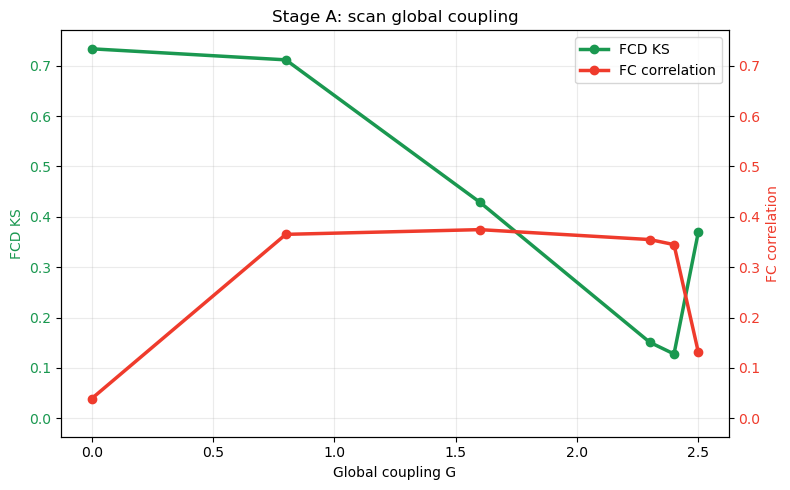

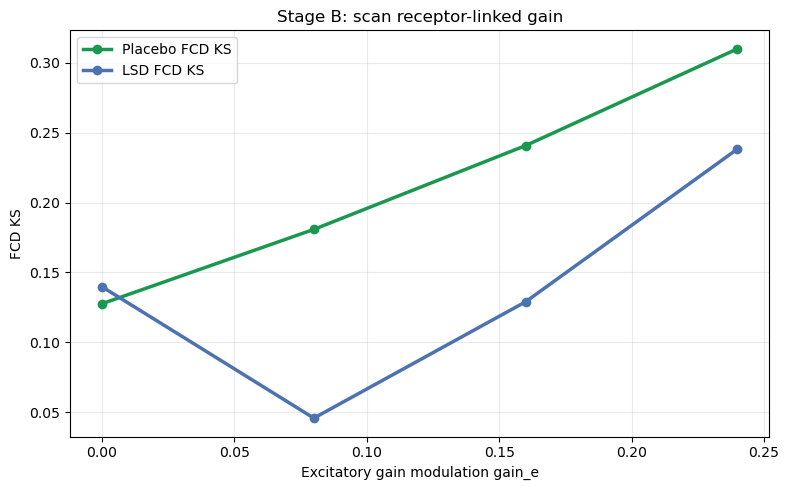

In [ ]:
# Cell 5: plot the fitting results
# Plotting is intentionally kept separate from the modeling workflow.

GREEN = "#1a9850"
RED = "#ef3b2c"
BLUE = "#4c72b0"


def plot_stage_a(result):
    """Plot Stage-A FCD KS and FC correlation across G."""
    g = result.grid["G"]
    fc_idx = result.target_names.index("fc_corr_z")
    fcd_idx = result.target_names.index("placebo_fcd")

    fc_mean = -result.target_losses[:, :, fc_idx].mean(axis=1)
    fcd_mean = result.target_losses[:, :, fcd_idx].mean(axis=1)

    fig, ax_left = plt.subplots(figsize=(8, 5))
    ax_right = ax_left.twinx()
    ax_left.plot(g, fcd_mean, color=GREEN, linewidth=2.5, marker="o", label="FCD KS")
    ax_right.plot(g, fc_mean, color=RED, linewidth=2.5, marker="o", label="FC correlation")

    ymin = min(float(np.min(fcd_mean)), float(np.min(fc_mean)), 0.0)
    ymax = max(float(np.max(fcd_mean)), float(np.max(fc_mean)))
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ax_left.set_ylim(ymin - pad, ymax + pad)
    ax_right.set_ylim(ymin - pad, ymax + pad)

    ax_left.set_xlabel("Global coupling G")
    ax_left.set_ylabel("FCD KS", color=GREEN)
    ax_right.set_ylabel("FC correlation", color=RED)
    ax_left.tick_params(axis="y", labelcolor=GREEN)
    ax_right.tick_params(axis="y", labelcolor=RED)
    ax_left.set_title("Stage A: scan global coupling")

    handles = [
        plt.Line2D([0], [0], color=GREEN, linewidth=2.5, marker="o", label="FCD KS"),
        plt.Line2D([0], [0], color=RED, linewidth=2.5, marker="o", label="FC correlation"),
    ]
    ax_left.legend(handles=handles, loc="best")
    ax_left.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_stage_b(result):
    """Plot Stage-B FCD KS for placebo and LSD targets across gain_e."""
    gain = result.grid["gain_e"]
    placebo_idx = result.target_names.index("placebo_fcd")
    lsd_idx = result.target_names.index("lsd_fcd")

    placebo = result.target_losses[:, :, placebo_idx].mean(axis=1)
    lsd = result.target_losses[:, :, lsd_idx].mean(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(gain, placebo, color=GREEN, linewidth=2.5, marker="o", label="Placebo FCD KS")
    ax.plot(gain, lsd, color=BLUE, linewidth=2.5, marker="o", label="LSD FCD KS")
    ax.set_xlabel("Excitatory gain modulation gain_e")
    ax.set_ylabel("FCD KS")
    ax.set_title("Stage B: scan receptor-linked gain")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


plot_stage_a(stage_a)
plot_stage_b(stage_b)